In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import heapq
import seaborn as sns

from environment.environment import GraphWorldMFG_MultiGroup
from trainer.amid_trainer_graph import GraphEdgeMFG_Trainer
from solver.solver import solve_multigroup, GraphMFG_OMD_EdgeSolver_MultiGroup
from visualization.visualizationh import plot_heatmap, compute_exploitability_multigroup, plot_losses, plot_losses_line

In [2]:
import os
from pathlib import Path
import yaml
import numpy as np
import torch

# 1. Configuration Loader
def load_config(config_path="config.yaml"):
    """Load configuration safely from a YAML file relative to working directory."""
    notebook_dir = Path(os.getcwd())
    config_file = notebook_dir / config_path
    
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    return config

# 2. Graph Environment Factory Pattern
def create_graph_mfg_from_config(config):
    """Factory function initializing the Graph MFG environment directly from your config."""
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Target Device: {device}")

    trainer_cfg = config["trainer"]
    
    # Extract Graph Configuration
    graph_cfg = config["graph"]
    num_nodes = graph_cfg["num_nodes"]
    
    # CRITICAL: Extract the list of lists matrix and convert to a PyTorch Tensor
    raw_matrix = graph_cfg["adjacency_matrix"]
    adjacency_matrix = torch.tensor(raw_matrix, dtype=torch.float32, device=device)
    
    # Process Group Data (Sinks and Sources are flat integers here, not grid tuples)
    groups = []
    for g in config["groups"]:
        groups.append({
            "source": int(g["source"]),
            "sink": int(g["sink"]),
            "mass": float(g["mass"])
        })
    
    solver_cfg = config["solver"]
    waiting_time = solver_cfg.get("waiting_time", 0)
    # Instantiate the Graph World Environment
    # (Matches your 'GraphWorldMFG_MultiGroup' class structure)
    env = GraphWorldMFG_MultiGroup(
        num_nodes=num_nodes,
        groups=groups,
        adjacency_matrix=adjacency_matrix,
        H = solver_cfg.get("H", None),
        device=device
    )
    
    # Create solvers for each group
    
    
    solvers = [
        GraphMFG_OMD_EdgeSolver_MultiGroup(
            env=env,
            group_idx=k,
            eta=solver_cfg["eta"],
            tau=solver_cfg["tau"],
            T=solver_cfg["T"],
            alpha=solver_cfg["alpha"],
            H=solver_cfg.get("H", None)
        )
        for k in range(env.K)
    ]

    trainer = GraphEdgeMFG_Trainer(env, solvers, leader_lr=trainer_cfg["leader_lr"])
    
    return env, solvers, trainer, config

In [3]:
config = load_config("config_graph.yaml")

env, solvers, trainer, config = create_graph_mfg_from_config(config)

# Training loop
theta_leader = torch.zeros((env.N, env.N), device=env.device)  # Initialize leader's strategy
#theta_leader[1,2] = 5.0
#theta_leader[2,1] = 5.0

Target Device: cpu


c:\Uzh\thesis\msc_code\thesis\environment\environment.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.A = torch.tensor(adjacency_matrix, dtype=torch.float32, device=device)


In [4]:
env.A.sum()

tensor(76.)

In [5]:
node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history, W_parts = solve_multigroup(env, solvers, T=50, W_max=15, theta_leader=theta_leader)

In [6]:
exploitability, V_best, V_pi = solvers[0].compute_exploitability(W_cong_history, W_max=15, theta_leader=theta_leader)
exploitability

0.04047966003417969

In [7]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(21.9083)

In [8]:
loss = 0
for i in range(env.H):
    cost = final_flows[i, 18] - 1
    loss = loss + cost
loss

tensor(-21.9083)

In [10]:
import itertools
import torch

def run_search(config, search_grid, probe_epochs=10, seed=0):
    """
    Grid search over hyperparameters. Rebuilds env/solvers/trainer FRESH for
    every combination (via create_graph_mfg_from_config), rather than mutating
    an existing trainer's solvers/optimizer in place -- this avoids any risk
    of leftover zeta/Adam-momentum state leaking between trials, which would
    make the comparison meaningless (the same "stale state" issue we hit
    repeatedly with reused solvers/optimizers throughout this project).

    Args:
        config: the loaded config dict (from load_config(...))
        search_grid: dict of param_name -> list of values to try, e.g.
            {"eta": [0.01, 0.02, 0.05], "tau": [0.02, 0.05], "leader_lr": [1e-4, 1e-3]}
        probe_epochs: SHORT run per combination -- you don't need the full 25+
            epochs to see whether a combination is trending well or badly.
            Run the winner for longer afterward, separately.
        seed: fixed across all trials for a fair comparison.

    Returns: list of dicts, one per combination, sorted best-first.
    """
    param_names = list(search_grid.keys())
    combinations = list(itertools.product(*search_grid.values()))
    results = []

    for combo in combinations:
        params = dict(zip(param_names, combo))

        # Apply this combination to a COPY of the config -- never mutate the
        # original, so every trial starts from the same known-good base.
        trial_config = {k: (v.copy() if isinstance(v, dict) else v) for k, v in config.items()}
        if "eta" in params:
            trial_config["solver"]["eta"] = params["eta"]
        if "tau" in params:
            trial_config["solver"]["tau"] = params["tau"]
        if "leader_lr" in params:
            trial_config["trainer"]["leader_lr"] = params["leader_lr"]
        # extend here for any other params you add to search_grid --
        # e.g. trial_config["solver"]["T"] = params["T"]

        torch.manual_seed(seed)
        env, solvers, trainer, _ = create_graph_mfg_from_config(trial_config)

        theta_leader = torch.zeros((env.N, env.N), device=env.device)
        node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history, W_parts = solve_multigroup(
            env, solvers, T=1, W_max=15, theta_leader=theta_leader
        )
        flows_previous = final_flows.detach()
        W_cong_history = W_cong_history.detach()

        social_losses = []
        exploitabilities = []
        diverged = False

        print(solvers[0].eta, solvers[0].tau)

        if solvers[0].eta < 0.05 or solvers[0].tau < 0.05: 
            trainer.OMDsteps = 100

            if solvers[0].eta == 0.02:
                trainer.OMDsteps = 150

            elif solvers[0].eta == 0.01:
                trainer.OMDsteps = 200

        for param_group in trainer.optimizer.param_groups:
            if param_group['lr'] == 1e-4:  
                probe_epochs = 140

        for param_group in trainer.optimizer.param_groups:
            if param_group['lr'] == 5e-4:
                probe_epochs = 125

        for param_group in trainer.optimizer.param_groups:
            if param_group['lr'] == 1e-3:
                probe_epochs = 110

        for param_group in trainer.optimizer.param_groups:
            if param_group['lr'] == 5e-3:
                probe_epochs = 95

        for param_group in trainer.optimizer.param_groups:
            if param_group['lr'] == 1e-2:
                probe_epochs = 80

        for epoch in range(1, probe_epochs + 1):
            try:
                social_loss, flows_new, W_cong_history_new, theta_leader_new, congestion_loss = trainer.train_step(
                    flows_previous, W_cong_history, epoch
                )
            except RuntimeError as e:
                # catches NaN/inf blowups so one bad combination doesn't kill the whole search
                print(f"  {params} -> diverged at epoch {epoch}: {e}")
                diverged = True
                break


            flows_previous = flows_new.detach()
            W_cong_history = W_cong_history_new.detach()

            loss_val = social_loss.item() if torch.is_tensor(social_loss) else social_loss
            if not torch.isfinite(torch.tensor(loss_val)):
                print(f"  {params} -> non-finite loss at epoch {epoch}")
                diverged = True
                break

            social_losses.append(loss_val)

        result = {
            "params": params,
            "diverged": diverged,
            "final_social_loss": social_losses[-1] if social_losses else float("inf"),
            "social_loss_trend": social_losses,  # keep the full trend, not just the endpoint --
                                                   # a combination that's still dropping steeply at
                                                   # probe_epochs may beat one that plateaued early
        }
        results.append(result)
        print(f"{params} -> final social loss: {result['final_social_loss']:.4f}" +
              (" (DIVERGED)" if diverged else ""))

    results.sort(key=lambda r: r["final_social_loss"])
    return results


if __name__ == "__main__":
    config = load_config("config_graph.yaml")

    search_grid = {
        "eta": [0.1],
        "tau": [0.05],
        "leader_lr": [1e-4, 5e-4 , 1e-3, 5e-3, 1e-2],
    }

    results = run_search(config, search_grid, probe_epochs=80, seed=0)

    print("\n" + "=" * 50)
    print("Top 5 combinations:")
    for r in results[:5]:
        print(f"  {r['params']}: final_loss={r['final_social_loss']:.4f}")

Target Device: cpu
0.1 0.05


c:\Uzh\thesis\msc_code\thesis\environment\environment.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.A = torch.tensor(adjacency_matrix, dtype=torch.float32, device=device)


torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.033519744873046875
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.019519805908203125
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.01741790771484375
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.014665603637695312
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.017862319946289062
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.019384384155273438
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.020322799682617188
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.020809173583984375
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.020494461059570312
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.020824432373046875
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.02127838134765625
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.021148681640625
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.020734786987304688
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.02030181884765625
torch.Size([50, 1, 50, 24, 24])
Exploita

In [9]:
seed = 1
torch.manual_seed(seed)
config = load_config("config_graph.yaml")

env, solvers, trainer, config = create_graph_mfg_from_config(config)

# Training loop
theta_leader = torch.zeros((env.N, env.N), device=env.device)  # Initialize leader's strategy
#theta_leader[1,2] = 5.0
#theta_leader[2,1] = 5.0

node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history, W_parts = solve_multigroup(env, solvers, T=1, W_max=100, theta_leader=theta_leader)

print("Starting Leader Infrastructure Optimization...")
print("-" * 50)
flows_previous = final_flows.detach()  # Detach to avoid backprop through the entire history
W_cong_history = W_cong_history.detach()  # Detach to avoid backprop
losses = []
losses_congestion = []
ratio = []

epochs = 35
for epoch in range(1, epochs + 1):
    
    # Execute one optimization step
    social_loss, flows_new, W_cong_history_new, theta_leader_new, congestion_loss = trainer.train_step(flows_previous, W_cong_history, epoch)
    
    # Pass the newly generated flows as the historical footprint for the next epoch
    flows_previous = flows_new.detach() 
    W_cong_history = W_cong_history_new.detach()
    theta_leader = theta_leader_new.detach()
    
    # Optional: Recompute or update W_cong_history based on flows_new if required, 
    # otherwise it continues to adapt based on the internal solve_multigroup loop.
    
    if epoch % 1 == 0:
        print(f"Epoch {epoch:02d}/{epochs} | Social Loss (Travel Time): {social_loss:.4f}")
        print(f"Epoch {epoch:02d}/{epochs} | COngestion Loss (Travel Time): {congestion_loss:.4f}")
        print(f"ratio={congestion_loss/social_loss:.3f}")

    ratio.append(congestion_loss/social_loss)
    losses.append(social_loss)
    losses_congestion.append(congestion_loss)



print("-" * 50)
print("Training Complete!") 

Target Device: cpu
Starting Leader Infrastructure Optimization...
--------------------------------------------------


c:\Uzh\thesis\msc_code\thesis\environment\environment.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.A = torch.tensor(adjacency_matrix, dtype=torch.float32, device=device)


torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.01776123046875
[tensor(4.9003), tensor(11.7830), tensor(13.8539)] tensor(30.5371) tensor(30.5371) tensor(36.5380)
Epoch 01/35 | Social Loss (Travel Time): 36.5380
Epoch 01/35 | COngestion Loss (Travel Time): 4.9003
ratio=0.134
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.06340789794921875
[tensor(6.4673), tensor(12.0289), tensor(12.6483)] tensor(31.1445) tensor(31.1445) tensor(37.2037)
Epoch 02/35 | Social Loss (Travel Time): 37.2037
Epoch 02/35 | COngestion Loss (Travel Time): 6.4673
ratio=0.174
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.045307159423828125
[tensor(4.2997), tensor(12.4053), tensor(13.5675)] tensor(30.2725) tensor(30.2725) tensor(36.5482)
Epoch 03/35 | Social Loss (Travel Time): 36.5482
Epoch 03/35 | COngestion Loss (Travel Time): 4.2997
ratio=0.118
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.0702972412109375
[tensor(4.3413), tensor(12.7553), tensor(12.6769)] tensor(29.7735) tensor(29.7735) tensor(36.22

In [13]:
node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history, W_parts = solve_multigroup(env, solvers, T=1, W_max=100, theta_leader=theta_leader)

print("Starting Leader Infrastructure Optimization...")
print("-" * 50)
flows_previous = final_flows.detach()  # Detach to avoid backprop through the entire history
W_cong_history = W_cong_history.detach()  # Detach to avoid backprop
losses = []
losses_congestion = []
ratio = []

epochs = 35
for epoch in range(1, epochs + 1):
    
    # Execute one optimization step
    social_loss, flows_new, W_cong_history_new, theta_leader_new, congestion_loss = trainer.train_step(flows_previous, W_cong_history, epoch)
    
    # Pass the newly generated flows as the historical footprint for the next epoch
    flows_previous = flows_new.detach() 
    W_cong_history = W_cong_history_new.detach()
    theta_leader = theta_leader_new.detach()
    
    # Optional: Recompute or update W_cong_history based on flows_new if required, 
    # otherwise it continues to adapt based on the internal solve_multigroup loop.
    
    if epoch % 1 == 0:
        print(f"Epoch {epoch:02d}/{epochs} | Social Loss (Travel Time): {social_loss:.4f}")
        print(f"Epoch {epoch:02d}/{epochs} | COngestion Loss (Travel Time): {congestion_loss:.4f}")
        print(f"ratio={congestion_loss/social_loss:.3f}")

    ratio.append(congestion_loss/social_loss)
    losses.append(social_loss)
    losses_congestion.append(congestion_loss)



print("-" * 50)
print("Training Complete!") 

Starting Leader Infrastructure Optimization...
--------------------------------------------------
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.026891708374023438
[tensor(8.5025), tensor(12.1868), tensor(0.0214)] tensor(20.7107) tensor(20.7107) tensor(26.7913)
Epoch 01/35 | Social Loss (Travel Time): 26.7913
Epoch 01/35 | COngestion Loss (Travel Time): 8.5025
ratio=0.317
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.027139663696289062
[tensor(8.5014), tensor(12.1865), tensor(0.0224)] tensor(20.7103) tensor(20.7103) tensor(26.7908)
Epoch 02/35 | Social Loss (Travel Time): 26.7908
Epoch 02/35 | COngestion Loss (Travel Time): 8.5014
ratio=0.317
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.028287887573242188
[tensor(8.4955), tensor(12.1870), tensor(0.0254)] tensor(20.7079) tensor(20.7079) tensor(26.7890)
Epoch 03/35 | Social Loss (Travel Time): 26.7890
Epoch 03/35 | COngestion Loss (Travel Time): 8.4955
ratio=0.317
torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.027782440185

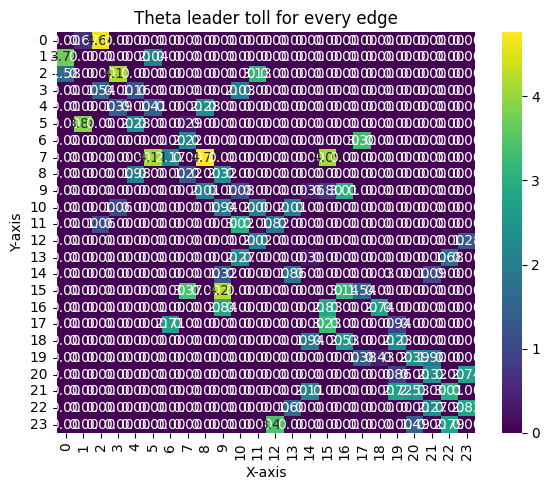

In [10]:
plot_heatmap(theta_leader * env.A, title = "Theta leader toll for every edge")

In [11]:
theta_leader * env.A

tensor([[0.0000, 0.6679, 4.6363, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [3.7162, 0.0000, 0.0000, 0.0000, 0.0000, 2.0362, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [1.5826, 0.0000, 0.0000, 4.1102, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 3.1271, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 1.5411, 0.0000, 1.1634, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 2.0321, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 1.3935, 0.0000, 1.4068, 0.0000, 0.0000, 2.2842,
         0.0000, 0.0000, 0.0000, 0.0000

In [13]:
node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history, W_parts = solve_multigroup(env, solvers, T=50, W_max=100, theta_leader=theta_leader)

In [14]:
exploitability, V_best, V_pi = solvers[0].compute_exploitability(W_cong_history, W_max=15, theta_leader=theta_leader)
exploitability

0.01781463623046875

In [15]:
a = trainer.compute_social_loss(final_flows, W_cong_history)
a

tensor(34.5406)

In [16]:
losses

[tensor(36.5380),
 tensor(37.2037),
 tensor(36.5482),
 tensor(36.2248),
 tensor(35.7572),
 tensor(35.8264),
 tensor(36.0383),
 tensor(36.0217),
 tensor(35.9099),
 tensor(35.7847),
 tensor(35.6935),
 tensor(35.6287),
 tensor(35.5370),
 tensor(35.4581),
 tensor(35.3584),
 tensor(35.2829),
 tensor(35.2741),
 tensor(35.2868),
 tensor(35.2851),
 tensor(35.2268),
 tensor(35.1072),
 tensor(34.9660),
 tensor(34.8610),
 tensor(34.8295),
 tensor(34.8377),
 tensor(34.8175),
 tensor(34.7775),
 tensor(34.7121),
 tensor(34.6486),
 tensor(34.6011),
 tensor(34.5691),
 tensor(34.5628),
 tensor(34.5751),
 tensor(34.5734),
 tensor(34.5443)]

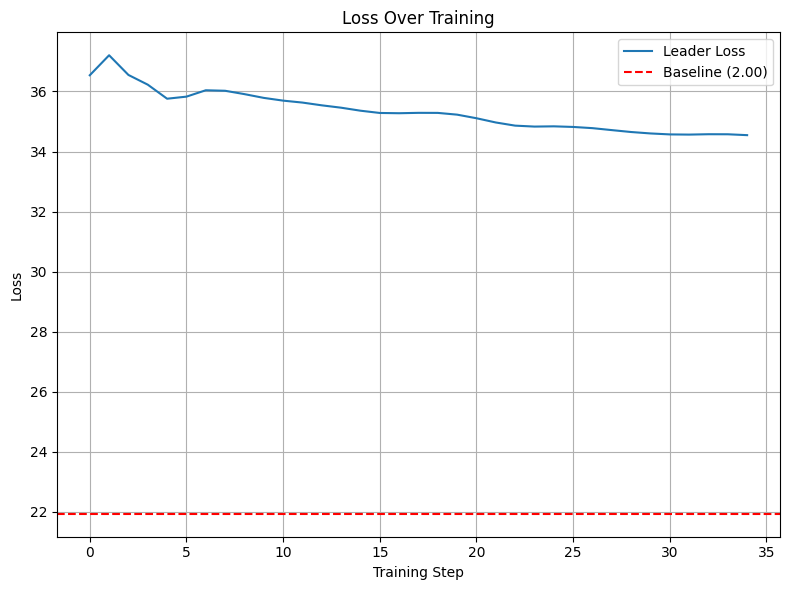

In [17]:
import torch
# Convert the tensors to plain floats inside the dictionary
loss_dict = {
    "Leader Loss": [loss.item() for loss in losses]
}

# Now you can pass it safely to your plotting function
plot_losses_line(loss_dict, yline=21.94)

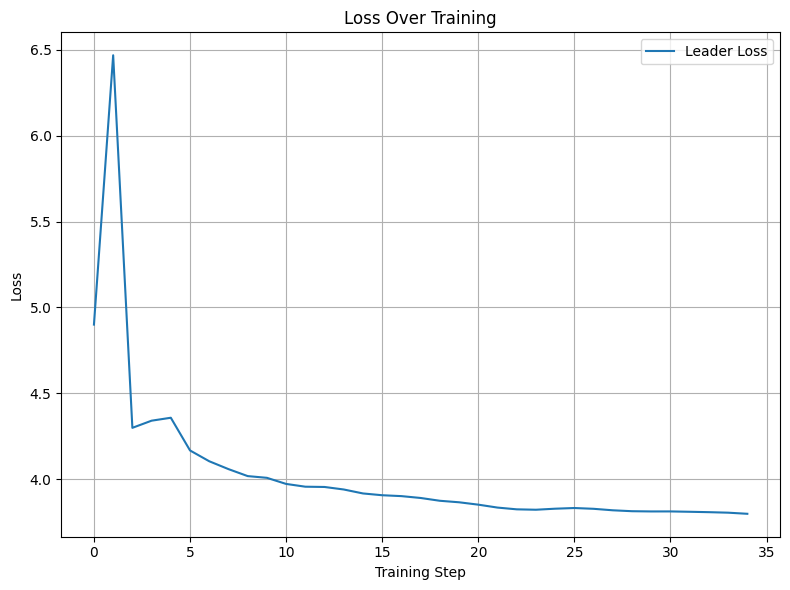

In [18]:
import torch
# Convert the tensors to plain floats inside the dictionary
loss_dict = {
    "Leader Loss": [loss.item() for loss in losses_congestion]
}

# Now you can pass it safely to your plotting function
plot_losses_line(loss_dict)

In [19]:
seed = 1
torch.manual_seed(seed)
config = load_config("config_graph.yaml")

env, solvers, trainer, config = create_graph_mfg_from_config(config)

# Training loop
theta_leader = torch.zeros((env.N, env.N), device=env.device)  # Initialize leader's strategy
#theta_leader[1,2] = 5.0
#theta_leader[2,1] = 5.0

node_mass, edge_occ, final_flows, policies, W_cong_history, zeta_history, W_parts = solve_multigroup(env, solvers, T=1, W_max=100, theta_leader=theta_leader)

print("Starting Leader Infrastructure Optimization...")
print("-" * 50)
flows_previous = final_flows.detach()  # Detach to avoid backprop through the entire history
W_cong_history = W_cong_history.detach()  # Detach to avoid backprop
losses = []
losses_congestion = []

epochs = 35
for epoch in range(1, epochs + 1):
    
    # Execute one optimization step
    social_loss, flows_new, W_cong_history_new, theta_leader_new, congestion_loss = trainer.train_step(flows_previous, W_cong_history, epoch)
    
    # Pass the newly generated flows as the historical footprint for the next epoch
    flows_previous = flows_new.detach() 
    W_cong_history = W_cong_history_new.detach()
    theta_leader = theta_leader_new.detach()
    
    # Optional: Recompute or update W_cong_history based on flows_new if required, 
    # otherwise it continues to adapt based on the internal solve_multigroup loop.
    
    if epoch % 1 == 0:
        print(f"Epoch {epoch:02d}/{epochs} | Social Loss (Travel Time): {social_loss:.4f}")
        print(f"Epoch {epoch:02d}/{epochs} | COngestion Loss (Travel Time): {congestion_loss:.4f}")
    
    losses.append(social_loss)
    losses_congestion.append(congestion_loss)

print("-" * 50)
print("Training Complete!") 

Target Device: cpu
Starting Leader Infrastructure Optimization...
--------------------------------------------------


c:\Uzh\thesis\msc_code\thesis\environment\environment.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.A = torch.tensor(adjacency_matrix, dtype=torch.float32, device=device)


torch.Size([50, 1, 50, 24, 24])
Exploitability: 0.01776123046875
[tensor(4.9003), tensor(11.7830), tensor(13.8539)] tensor(30.5371) tensor(30.5371) tensor(36.5380)


KeyboardInterrupt: 